In [11]:
import sys
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as s
from pyspark.sql.types import DoubleType, StringType

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Testing PySpark Example") \
    .master("local[*]") \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.driver.memory", "4g")\
    .getOrCreate()

In [12]:
#read in the reduced files

df = spark.read.parquet("2014-2017_FINAL_CLEANED", "2018-2026_FINAL_CLEANED")

df.printSchema()

root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)



In [13]:
total_entries = df.count()
print(total_entries)

164790247


In [14]:
cleaned_df = df

In [15]:
#extraction of the min and max ranges from the raw dataset 

min_max_passengers = cleaned_df.select(s.min(s.col("passenger_count")), s.max(s.col("passenger_count")),s.avg(s.col("passenger_count")))
min_max_passengers.show()

trip_distance = cleaned_df.select(s.min(s.col("trip_distance")), s.max(s.col("trip_distance")), s.avg(s.col("trip_distance")))
trip_distance.show()

fare_amount = cleaned_df.select(s.min(s.col("fare_amount")), s.max(s.col("fare_amount")), s.avg(s.col("fare_amount")))
fare_amount.show()

trip_amount = cleaned_df.select(s.min(s.col("tip_amount")), s.max(s.col("tip_amount")), s.avg(s.col("tip_amount")))
trip_amount .show()

total_amount = cleaned_df.select(s.min(s.col("total_amount")), s.max(s.col("total_amount")), s.avg(s.col("total_amount")))
total_amount.show()

trip_duration = cleaned_df.select(s.min(s.col("trip_duration")), s.max(s.col("trip_duration")), s.avg(s.col("trip_duration")))
trip_duration.show()

average_trip_speed = cleaned_df.select(s.min(s.col("average_trip_speed")), s.max(s.col("average_trip_speed")), s.avg(s.col("average_trip_speed")))
average_trip_speed.show()

+--------------------+--------------------+--------------------+
|min(passenger_count)|max(passenger_count)|avg(passenger_count)|
+--------------------+--------------------+--------------------+
|                 1.0|                 4.0|  1.3105865118340407|
+--------------------+--------------------+--------------------+

+------------------+------------------+------------------+
|min(trip_distance)|max(trip_distance)|avg(trip_distance)|
+------------------+------------------+------------------+
|              0.01|             19.99| 2.909317354685182|
+------------------+------------------+------------------+

+----------------+----------------+------------------+
|min(fare_amount)|max(fare_amount)|  avg(fare_amount)|
+----------------+----------------+------------------+
|            0.01|           100.0|13.378583431943088|
+----------------+----------------+------------------+

+---------------+---------------+-----------------+
|min(tip_amount)|max(tip_amount)|  avg(tip_amount)

In [17]:
#check correlations of numerical variables 

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

vectors = "correlation_features"
numerical_columns = ["passenger_count", "trip_distance", "fare_amount", "trip_duration", "average_trip_speed", "RatecodeID", "PULocationID", "DOLocationID"]
assembler = VectorAssembler(inputCols = numerical_columns, outputCol = vectors)
vector_df = assembler.transform(cleaned_df).select(vectors)

#obtain correlation matrix

correlation_mat = Correlation.corr(vector_df, vectors)

correlation_mat.collect()[0]['pearson({})'.format(vectors)].values


#"RatecodeID", "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount", "total_amount", "trip_duration", "average_trip_speed"

array([ 1.        ,  0.02664995,  0.0297481 ,  0.03034236,  0.00349229,
       -0.01843392, -0.00865791, -0.00736658,  0.02664995,  1.        ,
        0.9310589 ,  0.78128051,  0.64785988,  0.08533466, -0.08987855,
       -0.10489205,  0.0297481 ,  0.9310589 ,  1.        ,  0.85721745,
        0.48154493,  0.10569248, -0.08052901, -0.09680538,  0.03034236,
        0.78128051,  0.85721745,  1.        ,  0.15456265,  0.14068067,
       -0.06642899, -0.08395057,  0.00349229,  0.64785988,  0.48154493,
        0.15456265,  1.        ,  0.00645365, -0.07034735, -0.07725696,
       -0.01843392,  0.08533466,  0.10569248,  0.14068067,  0.00645365,
        1.        , -0.02653176, -0.02215928, -0.00865791, -0.08987855,
       -0.08052901, -0.06642899, -0.07034735, -0.02653176,  1.        ,
        0.09649352, -0.00736658, -0.10489205, -0.09680538, -0.08395057,
       -0.07725696, -0.02215928,  0.09649352,  1.        ])

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


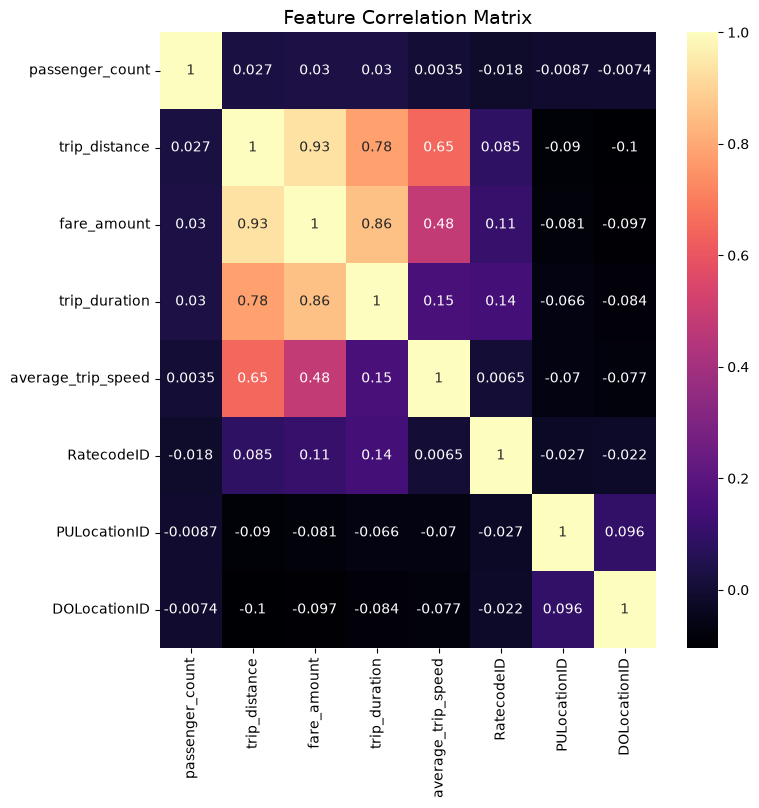

In [18]:
#plot it as a heatmap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn
import numpy as np

correlation_mat_converted = Correlation.corr(vector_df, "correlation_features")
pandas_df =  correlation_mat_converted.toPandas()
matrix_values = pandas_df.iloc[0,0]

matrix_df = pd.DataFrame(matrix_values.toArray(), index = numerical_columns, columns = numerical_columns)

plt.figure(figsize = (8, 8))


sbn.heatmap(matrix_df, annot = True, cmap = "magma")

plt.title("Feature Correlation Matrix", fontsize = 14)

plt.savefig("Pearson correlation matrix for numerical features")

plt.show()

In [19]:
#getting the average tips per year 
#versus the average fare per year

#add a year column to filter by

df = cleaned_df.withColumn("year",s.expr("""extract(YEAR from tpep_pickup_datetime)"""))
df.printSchema()


root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)
 |-- year: integer (nullable = true)



In [20]:
#calculate averages per year

average_tips_per_year = df.groupBy("year").agg(s.avg("tip_amount").alias("average_tip_amount")).orderBy("year")

average_tips_per_year.show()

+----+------------------+
|year|average_tip_amount|
+----+------------------+
|2014|1.4785042632170784|
|2015| 1.662374207779209|
|2016|1.7506348362803485|
|2017|1.7882965661757728|
|2018|1.8234433832826993|
|2019| 2.144008189586734|
|2020| 2.064701517770027|
|2021|2.3165328808507586|
|2022|2.6462143601489863|
|2023| 3.491641568864899|
|2024|3.5451908993617063|
|2025| 3.609424867654711|
+----+------------------+



C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


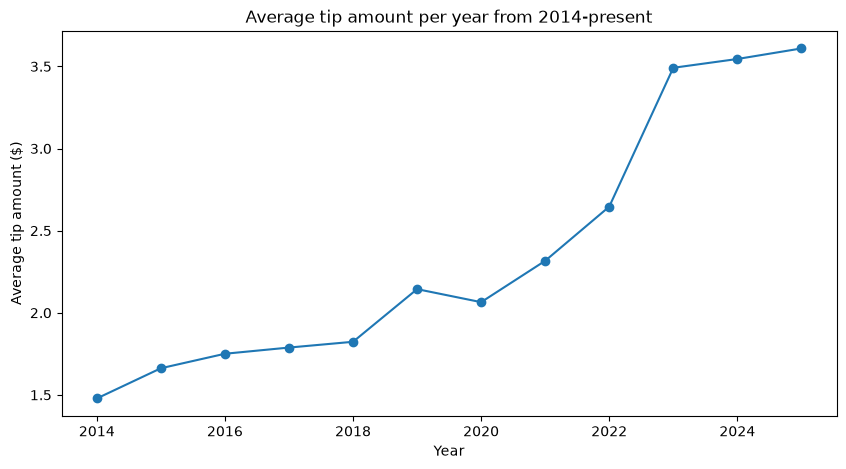

In [23]:
average_tips_per_year_pd = average_tips_per_year.toPandas()

plt.figure(figsize = (10,5))
plt.plot(average_tips_per_year_pd["year"], average_tips_per_year_pd["average_tip_amount"], marker = "o")
plt.title("Average tip amount per year from 2014-present")
plt.xlabel("Year")
plt.ylabel("Average tip amount ($)")

plt.savefig("Average tip amount per year from 2014-2026")